In [1]:
import numpy as np
import science_jubilee
from science_jubilee.calibration.CalibrationControlPanel import make_control_panel
from science_jubilee.calibration.CalibrationJoystick import make_PS4_control
from science_jubilee.Machine import Machine
from science_jubilee.tools.Tool import Tool
from harmonogram import harmonogram
from jinja2 import Environment, FileSystemLoader, select_autoescape
from tqdm import tqdm

ModuleNotFoundError: No module named 'pygame'

In [1]:
from dotenv import load_dotenv
import os
from jinja2 import Environment, FileSystemLoader, select_autoescape

from science_jubilee.hal.motion_driver import MotionDriver
from science_jubilee.hal.transport.http import HTTPTransport
from science_jubilee.tools.Tool import Tool
from science_jubilee.navigation import FreeNavigator
from science_jubilee.calibration.tool_gfiles import generate_tool_gfiles



load_dotenv("../.env.hardware")   # explicitly load your file
jubilee_address = os.environ["JUBILEE_ADDRESS"]
print(jubilee_address)

192.168.10.2


In [2]:
transport = HTTPTransport(address=jubilee_address)


In [3]:

driver = MotionDriver(transport)


driver.transport.connect() 

nav = FreeNavigator(driver)



### 1. Tool Definition
We need to give the Duet some information about the tool we are going to set up. First, we need to define the tool we're setting up by providing an index and a name. We can do this by adding an `M563` command to the `config.g` file. 

Run the following cell and copy the output. Paste it in your `config.g file` (to do so, go the the DuetWebControl interface, select System in the left hand toolabr, and then click on the `config.g` file). There will be a section almost at the bottom titled 'Tool Definitions'; paste the `M563` command there.

After saving the file, select 'restart the mainboard' on the pop-up window that appears.

In [4]:
tool_number = 0           # What is the number of the tool you are setting up? 
tool_name = "Camera" 
print(f'M563 P{tool_number} S"{tool_name}"')

M563 P0 S"Camera"


You'll need to rehome the machine after restarting the mainboard. Run the following cell to do so! Make sure your bed plate is clear.

In [5]:
nav.home_all()

### 2. Coursely place your parking post.
Take your parking post assembly and loosely fasten it to the rail approximately where you want it; you should still be able to move the parking post around to adjust it for X-axis position and parking post height. You'll need to align 2 tee-nuts on the Y axis rail, and you can access the m5 screws through the holes on top of the parking post.

### 3. Move the build plate
Drop your build plate down (positive Z values) such that any tools you’re about to mount will fully clear the bed.

In [49]:
nav.move_to(z=150)

### 4. Jog the carriage to somewhere close to the center of the printer bed.

In [50]:
nav.move_to(x=150, y=150)

### 5. With no active tool, manually place your tool against the lock carriage, and lock the tool onto the carriage
Run the following tool lock cell once you have placed the tool against the lock carriage.

In [93]:
nav.tool_lock()

In [89]:
nav.tool_unlock()

### 6. Jog the carriage to roughly where you want to end up across the X-axis.
Move to the approximate position where your parking post is.

In [51]:
tool_number = 0           # What is the number of the tool you are setting up? 
tool_name = "Camera" 
print(f'M563 P{tool_number} S"{tool_name}"')

M563 P0 S"Camera"


In [90]:
nav.move_to(x=290.5, y=290)

In [92]:
nav.move_to(x=290.5, y=338.5)

In [94]:
nav.y_clear = 270
nav.y_park = 338.5
nav.x_park = 290.5


In [95]:
print(nav.y_clear)
print(nav.y_park)
print(nav.x_park)

# Pickup and park moves should be 'manhattan' style to avoid collisions
# That is, we should move in a square block (X & Y seperately) rather than along the shortest path
# This ensures we don't hit parking posts by moving directly
# A default value of 60 works here!
manhattan_offset = 60 

270
338.5
290.5


In [96]:
template_path = "../src/science_jubilee/calibration/"
g_file_path = "../firmware/sys/"

env = Environment(loader= FileSystemLoader(template_path + "templates"))

In [97]:
# Generate tpre0.g, tpost0.g, tfree0.g and upload them to 0:/sys/ in one call
generate_tool_gfiles(
    tool_number=tool_number,
    x_park=nav.x_park,
    y_park=nav.y_park,
    y_clear=nav.y_clear,
    manhattan_offset=manhattan_offset,
    transport=transport,                # omit to only write files locally
)
transport.upload_files(
    ["../firmware/sys/tpre0.g", "../firmware/sys/tpost0.g", "../firmware/sys/tfree0.g"],
    destination="sys",
)


--- tpre0.g ---
; tpre0.g
; Runs after freeing the previous tool if the next tool is tool-0.
; Note: tool offsets are not applied at this point!

G90                   ; Ensure the machine is in absolute mode before issuing movements.
G0 X350.5 Y270 F20000 ; Rapid to the approach position without any current tool.
G60 S0                ; Save this position as the reference point from which to later apply new tool offsets.
--- tpost0.g ---
; tpost0.g
; called after firmware thinks Tool0 is selected
; Note: tool offsets are applied at this point!
; Note that commands preempted with G53 will NOT apply the tool offset.

; M116 P1                    ; Wait for set temperatures to be reached
; M302 P1                    ; Prevent Cold Extrudes, just in case temp setpoints are at 0

G90                        ; Ensure the machine is in absolute mode before issuing movements.

G53 G1 X290.5 F6000           ; Move to the pickup position with tool-1.
G53 G1 Y338.5 F6000
M98 P"/macros/tool_lock.g

['0:/sys/tpre0.g', '0:/sys/tpost0.g', '0:/sys/tfree0.g']

In [20]:
# Load your tool
tool = Tool(tool_number, tool_name)
nav.load_tool(tool)

AttributeError: 'FreeNavigator' object has no attribute 'load_tool'

In [25]:
nav.pickup_tool(tool)

True

In [24]:
nav.park_tool()

True

9.201402055489183 188.76279507429166 59.29739891227843 174.81441643264594



# Random pattern, try several times to get an output you like


(-1.118522064743867,
 1.1196939326175386,
 -1.6248630002160593,
 1.6951144740811723)

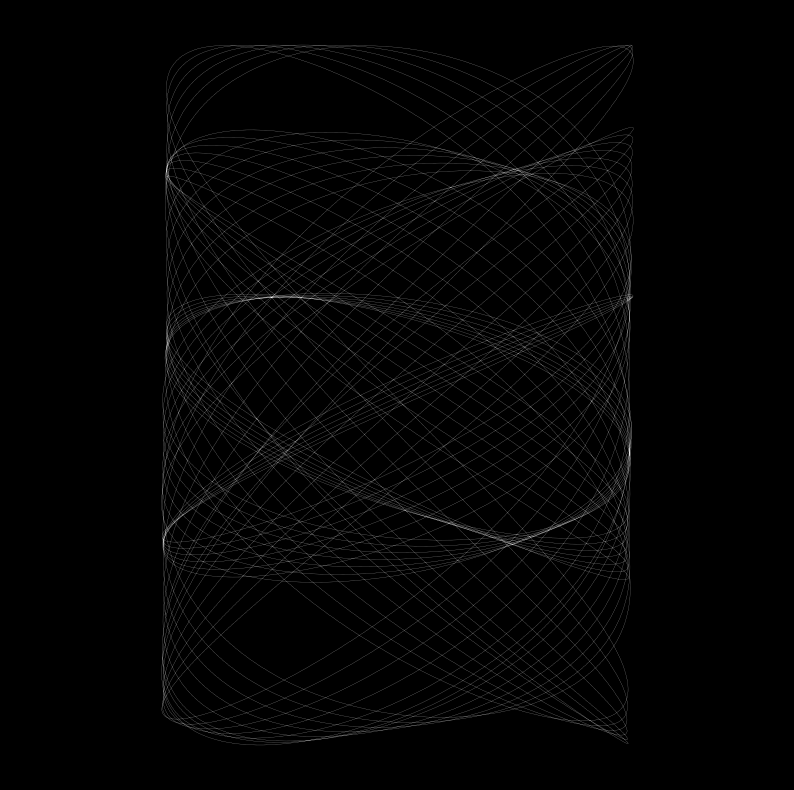

In [62]:
import matplotlib.pyplot as plt
max_val = 15 #s #number of points
num_val = int(1e4) #step size
X, Y = harmonogram(max_val, num_val)
X = (X + 2)*50
Y = (Y+2)*50
plt.axis("equal")

# Move to the first point:

In [63]:


print(X.min(), X.max(), Y.min(), Y.max())
m.move_to(x = X[0], y = Y[0])

49.160751302264394 150.8978420914192 26.30225333987256 177.21032035338308


# Set the pen height

In [64]:
make_PS4_control(m, "position_pen.csv")
# m.move_to(z=9.45)

PS4 Controller
PS button pressed.
End of recording


# Start drawing

In [ ]:
for (x,y) in tqdm(zip(X,Y)):
    m.move_to(x = x, y = y)

7793it [28:05,  4.68it/s]

F8 - C2 - F1 


Text(0.5, 0.98, 'F8 - C2 - F1 ')

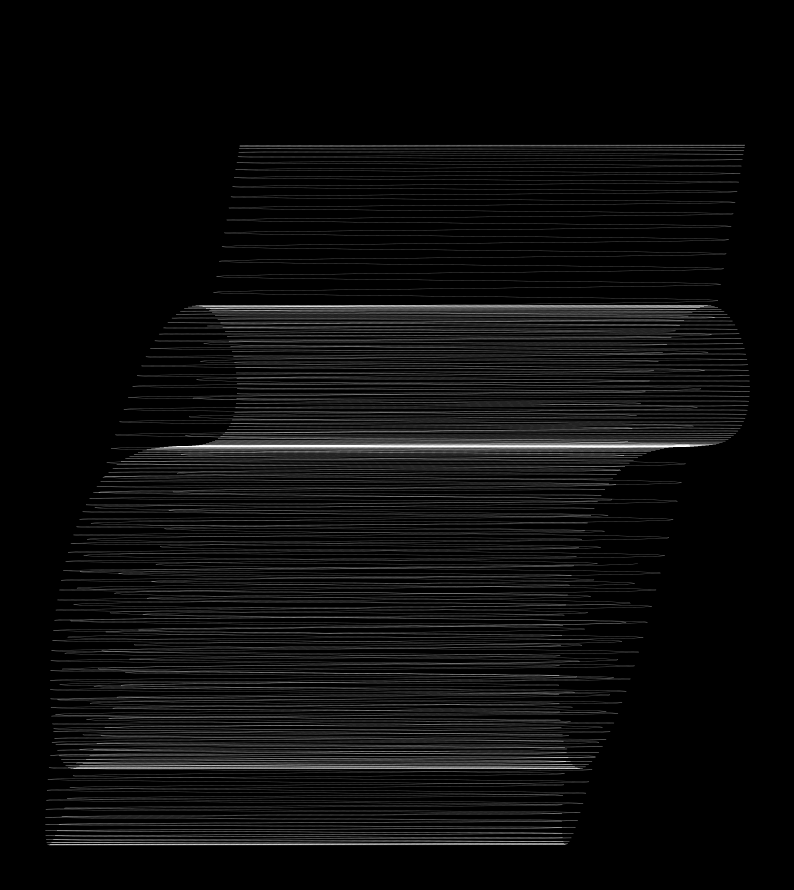

In [24]:
notes = ['A', 'A#','B','C','C#','D','D#','E','F','F#','G','G#']
values = [2**(i/12) for i in range(len(notes))]
note_val = dict(zip(notes,values))
octaves = np.arange(1,10,1)
octave_value = 2**(octaves.astype(float)-4)*440
octave_vals = dict(zip(octaves,octave_value))

full_keyboard = []
for i in octaves:
    full_keyboard+=([n+str(i) for n in notes])
    


def get_frequency(note,octave):
    base_freq = note_val[note]
    return octave_vals[octave] * base_freq

random_note = lambda :notes[np.random.randint(0,len(notes))]
random_octave = lambda :octaves[np.random.randint(0,len(octaves))]


max_T = 0.0001 #s
num_dt = int(1e5)
alpha1 = 1/1.5 # s-1
alpha2 = 1/2 # s-1
alpha3 = 1/2 # s-1
COS = np.random.rand()
#max_val = 10/(f2-f1)

phase1 = np.random.rand()*2*np.pi

Notes = [(random_note(),random_octave()) for _ in range(3)]
[f1,f2,f3] = [get_frequency(*Notes[i]) for i in range(3)]
print(f'{Notes[0][0][0]}{Notes[0][1]} - {Notes[1][0][0]}{Notes[1][1]} - {Notes[2][0][0]}{Notes[2][1]} ')

max_T = 100/(f2-f1)
t = np.log(np.logspace(0,max_T,num_dt))
F1 = lambda x: np.exp(-2*alpha1*x)*np.cos(2*np.pi*f1*t)
F2 = lambda x: np.exp(-2*alpha2*x)*np.cos(2*np.pi*f2*t)
F3 = lambda x: np.exp(-2*alpha3*x)*np.cos(2*np.pi*f3*t)


fig= plt.figure(figsize = (10,10))
X = F1(t) + F3(t)*COS
Y = F2(t)*np.cos(phase1) + F3(t)*(1-COS**2)**(1/2)
plt.plot(X,Y,'w',linewidth = 0.15,linestyle='dashed')

#plt.plot(F1(t)-F2(t)*np.cos(phase1),F2(t)*np.sin(phase1)+F1(t),'w',linewidth = 0.15,linestyle='dashed')
ax = plt.gca()
fig.patch.set_facecolor('k')
ax.axis('off')
fig.suptitle(f'{Notes[0][0][0]}{Notes[0][1]} - {Notes[1][0][0]}{Notes[1][1]} - {Notes[2][0][0]}{Notes[2][1]} ')